In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
x=np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
y=np.array([[0],[1],[0],[1]])
x = x**2
x = x**3
x = x**5
# add bias term as a column of ones on the left
x = np.concatenate((np.ones((x.shape[0], 1)), x), axis=1)
theta = np.zeros((x.shape[1], 1))


In [5]:
z=np.dot(x,theta)
print(z)
# m=len(x)
# for x in range(m):
#     dot_product=np.dot(x,theta)
#     print(dot_product)

[[0.]
 [0.]
 [0.]
 [0.]]


In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [7]:
print(sigmoid(z))

[[0.5]
 [0.5]
 [0.5]
 [0.5]]


In [8]:
def compute_cost(x, y, theta):
    m = len(y)
    h = sigmoid(np.dot(x, theta))
    epsilon = 1e-5
    cost = (1/m) * (-y.T @ np.log(h + epsilon) - (1 - y).T @ np.log(1 - h + epsilon))
    return np.squeeze(cost)        # return a scalar, not an array


In [9]:
def gradient(x,y,theta):
    m=len(y)
    h=sigmoid(np.dot(x,theta))
    grad=(1/m)*np.dot(x.T,(h-y))
    return grad

In [10]:
# ----- Compute -----
cost_value = compute_cost(x, y, theta)
print("Initial Cost:", cost_value)

grad_value = gradient(x, y, theta)
print("Gradient:", grad_value)

Initial Cost: 0.6931271807599427
Gradient: [[ 0.00000000e+00]
 [-5.81634534e+17]
 [-1.13850619e+18]
 [-4.50508799e+17]]


In [11]:
def gradient_descent(x, y, theta, alpha=0.01, iteration=1000):
    m = len(y)
    cost_history = []

    for _ in range(iteration):
        h = sigmoid(np.dot(x, theta))
        theta = theta - (alpha/m) * np.dot(x.T, (h - y))
        cost = compute_cost(x, y, theta)
        cost_history.append(cost)
        # if i % 100 == 0:
        #     print(f"Iteration {i}: Cost = {cost:.2f}")
    
    return theta, cost_history

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16244\3196251242.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Optimized Theta: [[-2.49250000e+00]
 [ 2.22574492e+16]
 [ 3.44618794e+16]
 [ 1.05063958e+16]]


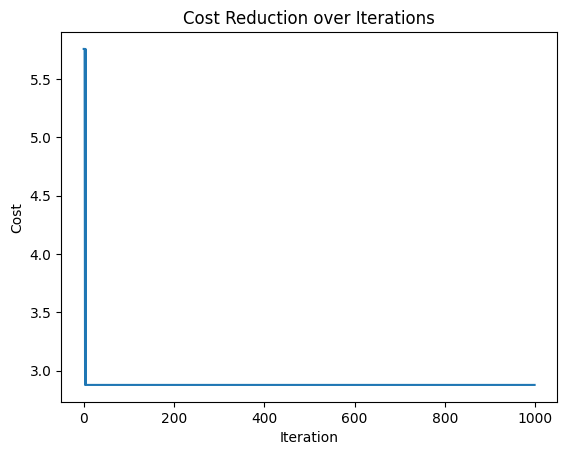

In [12]:
theta_final, cost_history = gradient_descent(x, y, theta, alpha=0.01, iteration=1000)
print("Optimized Theta:", theta_final)
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Reduction over Iterations")
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_16244\2509082027.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta1 = float(theta_final[0]) # clean scalar
C:\Users\lenovo\AppData\Local\Temp\ipykernel_16244\2509082027.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta2 = float(theta_final[1]) # clean scalar
C:\Users\lenovo\AppData\Local\Temp\ipykernel_16244\2509082027.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta3 = float(theta_final[2]) # cl

NameError: name 'xx3' is not defined

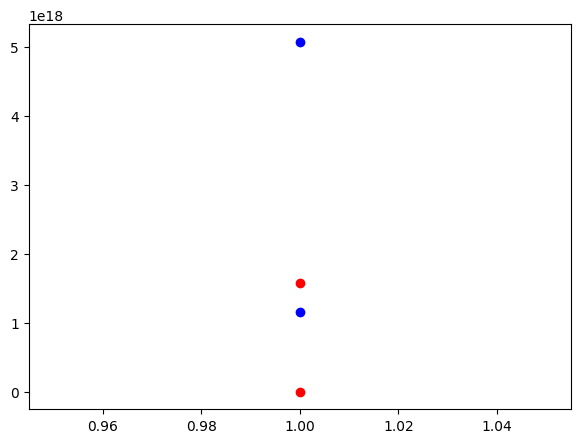

In [15]:

# ----- 2D Visualization -----
# Take first two features (x1, x2)
x_vis = x[:, :2]               # shape (3,2)
theta1 = float(theta_final[0]) # clean scalar
theta2 = float(theta_final[1]) # clean scalar
theta3 = float(theta_final[2]) # clean scalar (used as bias)

# Create grid
x1_vals = np.linspace(x_vis[:,0].min(), x_vis[:,0].max(), 50)
x2_vals = np.linspace(x_vis[:,1].min(), x_vis[:,1].max(), 50)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

# Logistic model: z = θ1*x1 + θ2*x2 + θ3
z = theta1*xx1 + theta2*xx2 + theta3
# Probability
h = sigmoid(z)

# Plot training data
plt.figure(figsize=(7,5))
plt.scatter(x_vis[y.flatten()==0,0], x_vis[y.flatten()==0,1], color='red', label='Class 0')
plt.scatter(x_vis[y.flatten()==1,0], x_vis[y.flatten()==1,1], color='blue', label='Class 1')

# Decision boundary (probability = 0.5)
plt.contour(xx1, xx2,xx3, h, levels=[0.5], colors='green')

plt.xlabel("x1 feature")
plt.ylabel("x2 feature")
plt.title("2D Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'theta1' is not defined

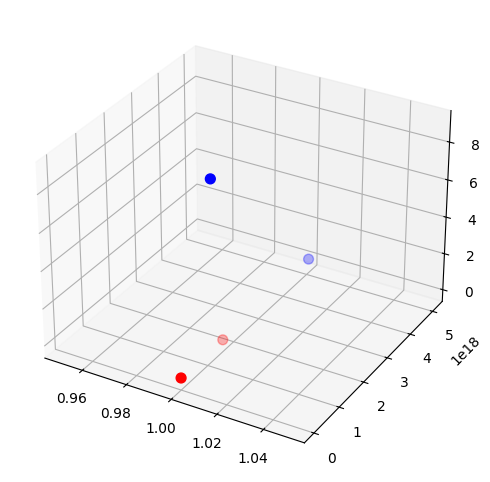

In [14]:
# ----- 3D Visualization -----
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

# Plot training data
ax.scatter(x[y.flatten()==0,0], x[y.flatten()==0,1], x[y.flatten()==0,2],
           color='red', label='Class 0', s=50)
ax.scatter(x[y.flatten()==1,0], x[y.flatten()==1,1], x[y.flatten()==1,2],
           color='blue', label='Class 1', s=50)

# Create meshgrid for (x1, x2)
x1_vals = np.linspace(x[:,0].min(), x[:,0].max(), 30)
x2_vals = np.linspace(x[:,1].min(), x[:,1].max(), 30)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

# Decision boundary plane: θ₁x₁ + θ₂x₂ + θ₃x₃ = 0 → x₃ = -(θ₁x₁ + θ₂x₂)/θ₃
xx3 = -(theta1 * xx1 + theta2 * xx2) / (theta3 + 1e-8)

# Plot the decision plane
ax.plot_surface(xx1, xx2, xx3, alpha=0.4, color='green', label='Decision Plane')

# Labels and view
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('3D Logistic Regression Decision Plane')
ax.legend()
ax.view_init(elev=25, azim=45)  # Rotate for better 3D view
plt.show()

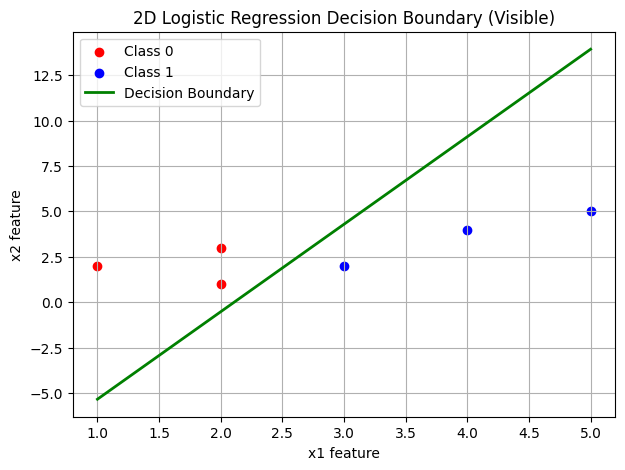

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ----- New 2D Dataset (Clearly separable) -----
x = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],
    [4, 4],
    [5, 5],
])
y = np.array([[0], [0], [0], [1], [1], [1]])   # two classes

# Add bias term (x0 = 1)
x = np.hstack([np.ones((x.shape[0], 1)), x])  # shape (6, 3)
theta = np.zeros((x.shape[1], 1))

# ----- Functions -----
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(x, y, theta):
    m = len(y)
    h = sigmoid(np.dot(x, theta))
    epsilon = 1e-5
    cost = (1/m) * (-np.dot(y.T, np.log(h + epsilon)) - np.dot((1 - y).T, np.log(1 - h + epsilon)))
    return np.squeeze(cost)

def gradient_descent(x, y, theta, alpha=0.1, iteration=1000):
    m = len(y)
    for i in range(iteration):
        h = sigmoid(np.dot(x, theta))
        theta = theta - (alpha/m) * np.dot(x.T, (h - y))
    return theta

# ----- Train Model -----
theta_final = gradient_descent(x, y, theta)

# ----- 2D Decision Boundary Visualization -----
# θ0*x0 + θ1*x1 + θ2*x2 = 0 → x2 = -(θ0 + θ1*x1) / θ2
theta0, theta1, theta2 = theta_final.flatten()

x1_vals = np.linspace(x[:,1].min(), x[:,1].max(), 100)
x2_vals = -(theta0 + theta1*x1_vals) / theta2

# Plot points
plt.figure(figsize=(7,5))
plt.scatter(x[y.flatten()==0,1], x[y.flatten()==0,2], color='red', label='Class 0')
plt.scatter(x[y.flatten()==1,1], x[y.flatten()==1,2], color='blue', label='Class 1')

# Plot decision boundary line
plt.plot(x1_vals, x2_vals, color='green', linewidth=2, label='Decision Boundary')

plt.xlabel("x1 feature")
plt.ylabel("x2 feature")
plt.title("2D Logistic Regression Decision Boundary (Visible)")
plt.legend()
plt.grid(True)
plt.show()


In [17]:
new_inputs=np.array([[1,2,3],[4,5,6]])
predictions=sigmoid(np.dot(new_inputs,theta_final))
print("Predictions for new inputs:", predictions)


Predictions for new inputs: [[1.30158406e-01]
 [5.27042178e-06]]


Predicted Probabilities:
 [[0.62277365]
 [0.65483123]]
Predicted Classes:
 [[1]
 [1]]


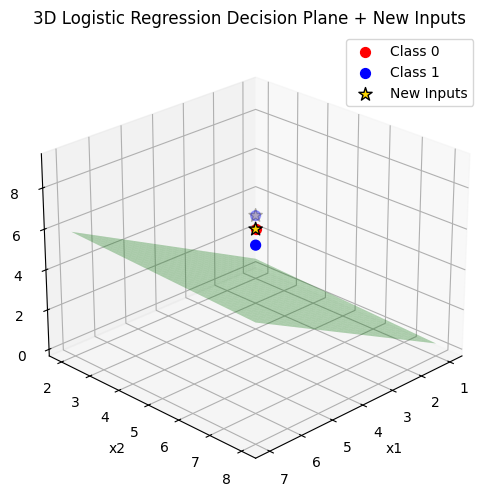

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----- Data (3 features) -----
x = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])
y = np.array([[1],[0],[1]])
theta = np.zeros((x.shape[1], 1))   # shape (3,1)

# ----- Functions -----
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gradient_descent(x, y, theta, alpha=0.01, iteration=1000):
    m = len(y)
    for i in range(iteration):
        h = sigmoid(np.dot(x, theta))
        theta = theta - (alpha/m) * np.dot(x.T, (h - y))
    return theta

# ----- Train Model -----
theta_final = gradient_descent(x, y, theta)
theta1, theta2, theta3 = theta_final.flatten()

# ----- New Inputs -----
new_inputs = np.array([[1,2,3],
                       [4,5,6]])
predictions = sigmoid(np.dot(new_inputs, theta_final))
predicted_classes = (predictions >= 0.5).astype(int)

print("Predicted Probabilities:\n", predictions)
print("Predicted Classes:\n", predicted_classes)

# ----- 3D Plot -----
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

# Training points
ax.scatter(x[y.flatten()==0,0], x[y.flatten()==0,1], x[y.flatten()==0,2], color='red', label='Class 0', s=50)
ax.scatter(x[y.flatten()==1,0], x[y.flatten()==1,1], x[y.flatten()==1,2], color='blue', label='Class 1', s=50)

# Decision plane θ1*x1 + θ2*x2 + θ3*x3 = 0
x1_vals = np.linspace(x[:,0].min(), x[:,0].max(), 30)
x2_vals = np.linspace(x[:,1].min(), x[:,1].max(), 30)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)
xx3 = -(theta1*xx1 + theta2*xx2) / (theta3 + 1e-8)
ax.plot_surface(xx1, xx2, xx3, alpha=0.3, color='green')

# New input predictions
ax.scatter(new_inputs[:,0], new_inputs[:,1], new_inputs[:,2],
           color='gold', edgecolor='black', s=100, marker='*', label='New Inputs')

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('3D Logistic Regression Decision Plane + New Inputs')
ax.legend()
ax.view_init(elev=25, azim=45)
plt.show()


manual code?


In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
x=np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
y=np.array([[0],[1],[0],[1]])

In [30]:
print(x)
# add bias term (add a column of ones as the first column)
x = np.hstack([np.ones((x.shape[0], 1)), x])
print(x)
# initialize theta as a column vector matching number of features (columns) in x
theta = np.array([[-5], [1], [1], [1]]) 
print(theta)

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
[[ 1.  1.  2.  3.]
 [ 1.  4.  5.  6.]
 [ 1.  7.  8.  9.]
 [ 1. 10. 11. 12.]]
[[-5]
 [ 1]
 [ 1]
 [ 1]]


In [31]:
# theta = np.zeros((x.shape[1], 1))
# print(theta)

In [32]:
z=np.dot(x,theta)
print(z.shape)


(4, 1)


In [33]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [34]:
def loss_function(theta,h, y):
    m = len(y)
    epsilon = 1e-5
    loss = (1/m) * (-y.T @ np.log(h + epsilon) - (1 - y).T @ np.log(1 - h + epsilon))
    return np.squeeze(loss)        # return a scalar, not an array  

In [35]:
def gradient(x,y,theta):
    m=len(y)
    h=sigmoid(np.dot(x,theta))
    grad=(1/m)*np.dot(x.T,(h-y))
    return grad 

In [36]:
def gradient_descent(x, y, theta, alpha=0.01, iteration=1000):
    m = len(y)
    cost_history = []

    for _ in range(iteration):
        h = sigmoid(np.dot(x, theta))
        theta = theta - (alpha/m) * np.dot(x.T, (h - y))
        cost = loss_function(x, y, theta)
        cost_history.append(cost)
    
    return theta, cost_history  

In [37]:
theta,cost_history=gradient_descent(x,y,theta,alpha=0.01,iteration=1000)
print("Optimized Theta:", theta)

Optimized Theta: [[-4.55409812]
 [-0.27386355]
 [ 0.17203833]
 [ 0.6179402 ]]


In [38]:
print("Final parameters θ:", theta)
print("Final loss:", cost_history[-1])

Final parameters θ: [[-4.55409812]
 [-0.27386355]
 [ 0.17203833]
 [ 0.6179402 ]]
Final loss: -7.846468241669806


In [44]:
predict=(1/1+np.exp(-z))
predict=(predict>=0.5).astype(int)
print("classes predicttion form of ",predict.ravel())

classes predicttion form of  [1 1 1 ... 1 1 1]


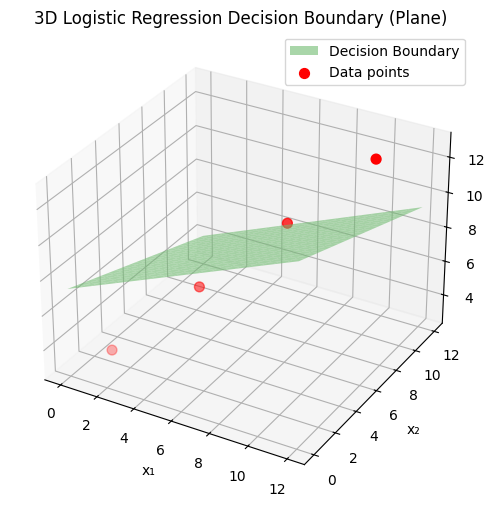

In [39]:
# Create grid of x1 and x2 values
x1_vals = np.linspace(0, 12, 20)
x2_vals = np.linspace(0, 12, 20)
x1, x2 = np.meshgrid(x1_vals, x2_vals)

# Compute x3 for decision boundary plane
# θ0 + θ1*x1 + θ2*x2 + θ3*x3 = 0  →  x3 = -(θ0 + θ1*x1 + θ2*x2)/θ3
x3 = -(theta[0] + theta[1]*x1 + theta[2]*x2) / theta[3]

# Plot the 3D decision boundary plane
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(x1, x2, x3, color='lightgreen', alpha=0.6, label='Decision Boundary')

# Plot original data points
ax.scatter(x[:,1], x[:,2], x[:,3], color='red', s=50, label='Data points')

# Labels
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_zlabel("x₃")
ax.set_title("3D Logistic Regression Decision Boundary (Plane)")

plt.legend()
plt.show()

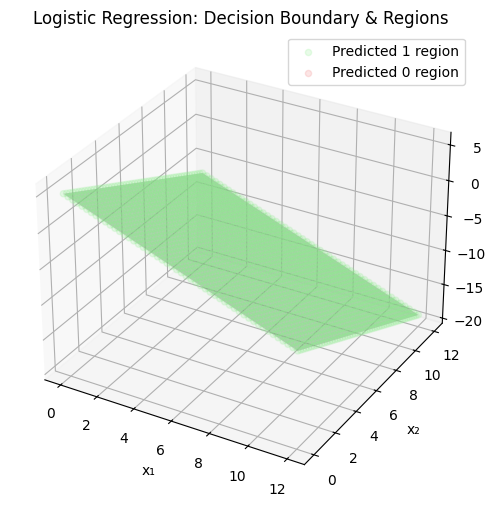

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Example data and parameters
theta = np.array([[-5], [1], [1], [1]])

x1_vals = np.linspace(0, 12, 50)
x2_vals = np.linspace(0, 12, 50)
x1, x2 = np.meshgrid(x1_vals, x2_vals)

# Equation of decision boundary: θ₀ + θ₁x₁ + θ₂x₂ + θ₃x₃ = 0
x3 = -(theta[0] + theta[1]*x1 + theta[2]*x2) / theta[3]

# Compute sigmoid probabilities for coloring regions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = theta[0] + theta[1]*x1 + theta[2]*x2 + theta[3]*x3
prob = sigmoid(z)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Decision boundary plane
ax.plot_surface(x1, x2, x3, color='gray', alpha=0.3)

# Color regions
ax.scatter(x1[prob>=0.5], x2[prob>=0.5], x3[prob>=0.5], color='lightgreen', alpha=0.2, label='Predicted 1 region')
ax.scatter(x1[prob<0.5], x2[prob<0.5], x3[prob<0.5], color='lightcoral', alpha=0.2, label='Predicted 0 region')

# Labels
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_zlabel("x₃")
ax.set_title("Logistic Regression: Decision Boundary & Regions")
ax.legend()
plt.show()


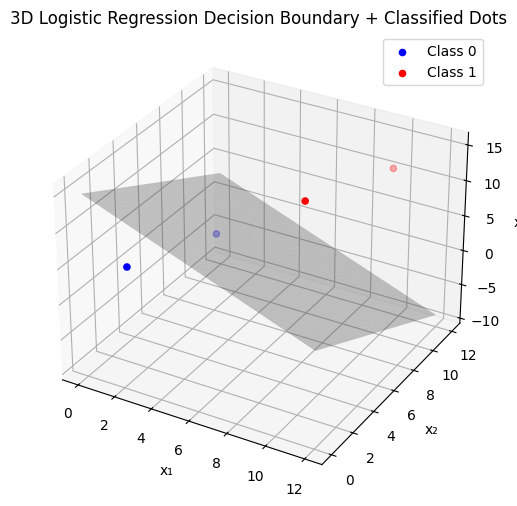

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------
# 1) Data points (your sample features)
# ------------------------------------------------
X = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12]
])
y = np.array([0, 0, 1, 1])  # true class labels

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Example theta values (try changing these)
theta = np.array([[-15], [1], [1], [1]])

# ------------------------------------------------
# 2) Decision boundary plane (θ₀ + θ₁x₁ + θ₂x₂ + θ₃x₃ = 0)
# ------------------------------------------------
x1_vals = np.linspace(0, 12, 50)
x2_vals = np.linspace(0, 12, 50)
x1, x2 = np.meshgrid(x1_vals, x2_vals)
x3 = -(theta[0] + theta[1]*x1 + theta[2]*x2) / theta[3]

# ------------------------------------------------
# 3) Plot
# ------------------------------------------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Decision boundary plane
ax.plot_surface(x1, x2, x3, color='gray', alpha=0.3)

# Class points
ax.scatter(X[y==0, 0], X[y==0, 1], X[y==0, 2], color='blue', label='Class 0')
ax.scatter(X[y==1, 0], X[y==1, 1], X[y==1, 2], color='red', label='Class 1')

# Labels
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_zlabel("x₃")
ax.set_title("3D Logistic Regression Decision Boundary + Classified Dots")
ax.legend()
plt.show()
